# 🤖 CVerify — NLP Model Comparison for Resume Job-Role Classification

---

## 📋 Project Summary

| Section | Description |
|---------|-------------|
| **1. Setup & Imports** | Libraries and path configuration |
| **2. Data Exploration (EDA)** | Dataset shape, category distribution, text stats |
| **3. Text Preprocessing** | Cleaning, TF-IDF vectorization |
| **4. Model 1 — TF-IDF + Logistic Regression** | Fast interpretable baseline |
| **5. Model 2 — TF-IDF + Random Forest** | Project's current model |
| **6. Model 3 — TF-IDF + Linear SVC** | State-of-the-art for sparse text |
| **7. Full Comparison Dashboard** | Metrics, confusion matrices, per-category F1 |
| **8. Best Model Export** | Save `.pkl` for production integration |
| **9. PDF Integration Demo** | How the chosen model processes real PDFs |
| **10. Conclusion** | Recommendation for the project |

---

### 🎯 Task: Multi-class Job-Role Classification

**Input:** Raw resume text (extracted from PDF)  
**Output:** One of **24 job categories** (ACCOUNTANT, IT, HEALTHCARE, …)  
**Dataset:** [Kaggle — Resume Dataset](https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset)  
**Records:** 2,484 resumes  

> **Why this matters?** The existing `pdf_parser.py` always returns `Job Role = None`.  
> This notebook trains and selects the best NLP model to fix that.

## 📦 Section 1: Setup & Imports

In [1]:
# ============================================================
#  IMPORTS
# ============================================================
import os, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# NLP / Text
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

# Persistence
import joblib

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(' All imports successful!')
print('='*60)
print(' NLP MODELS TO COMPARE:')
print('   Model 1 → TF-IDF + Logistic Regression  (baseline)')
print('   Model 2 → TF-IDF + Random Forest        (project model)')
print('   Model 3 → TF-IDF + Linear SVC           (best for sparse text)')
print('='*60)

 All imports successful!
 NLP MODELS TO COMPARE:
   Model 1 → TF-IDF + Logistic Regression  (baseline)
   Model 2 → TF-IDF + Random Forest        (project model)
   Model 3 → TF-IDF + Linear SVC           (best for sparse text)


In [2]:
# ============================================================
#  CONFIGURATION — works on both Kaggle and local machine
# ============================================================
ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    CSV_PATH   = '/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv'
    PDF_BASE   = Path('/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data')
    OUTPUT_DIR = Path('/kaggle/working')
else:
    # ---------- local paths (adjust if needed) ----------
    _here      = Path().resolve()
    _project   = _here.parents[0] if _here.name == 'scripts' else _here
    CSV_PATH   = str(_project / 'backend' / 'data' / 'Resume' / 'Resume.csv')
    PDF_BASE   = _project / 'backend' / 'data' / 'data' / 'data'
    OUTPUT_DIR = _project / 'backend' / 'models'
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f' Environment : {"Kaggle" if ON_KAGGLE else "Local"}')
print(f' CSV path    : {CSV_PATH}')
print(f' PDF folder  : {PDF_BASE}')
print(f' Output dir  : {OUTPUT_DIR}')
print(f' CSV exists  : {os.path.exists(CSV_PATH)}')

 Environment : Kaggle
 CSV path    : /kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv
 PDF folder  : /kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data
 Output dir  : /kaggle/working
 CSV exists  : True


## 📊 Section 2: Data Exploration (EDA)

In [3]:
# ============================================================
#  LOAD DATASET
# ============================================================
df = pd.read_csv(CSV_PATH)

print('='*60)
print(' DATASET OVERVIEW')
print('='*60)
print(f'Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns        : {df.columns.tolist()}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')
print(f'Categories     : {df["Category"].nunique()}')
print()
print('Category distribution:')
print(df['Category'].value_counts().to_string())

df.head(3)

 DATASET OVERVIEW
Shape          : 2,484 rows × 4 columns
Columns        : ['ID', 'Resume_str', 'Resume_html', 'Category']
Missing values : 0
Duplicates     : 0
Categories     : 24

Category distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


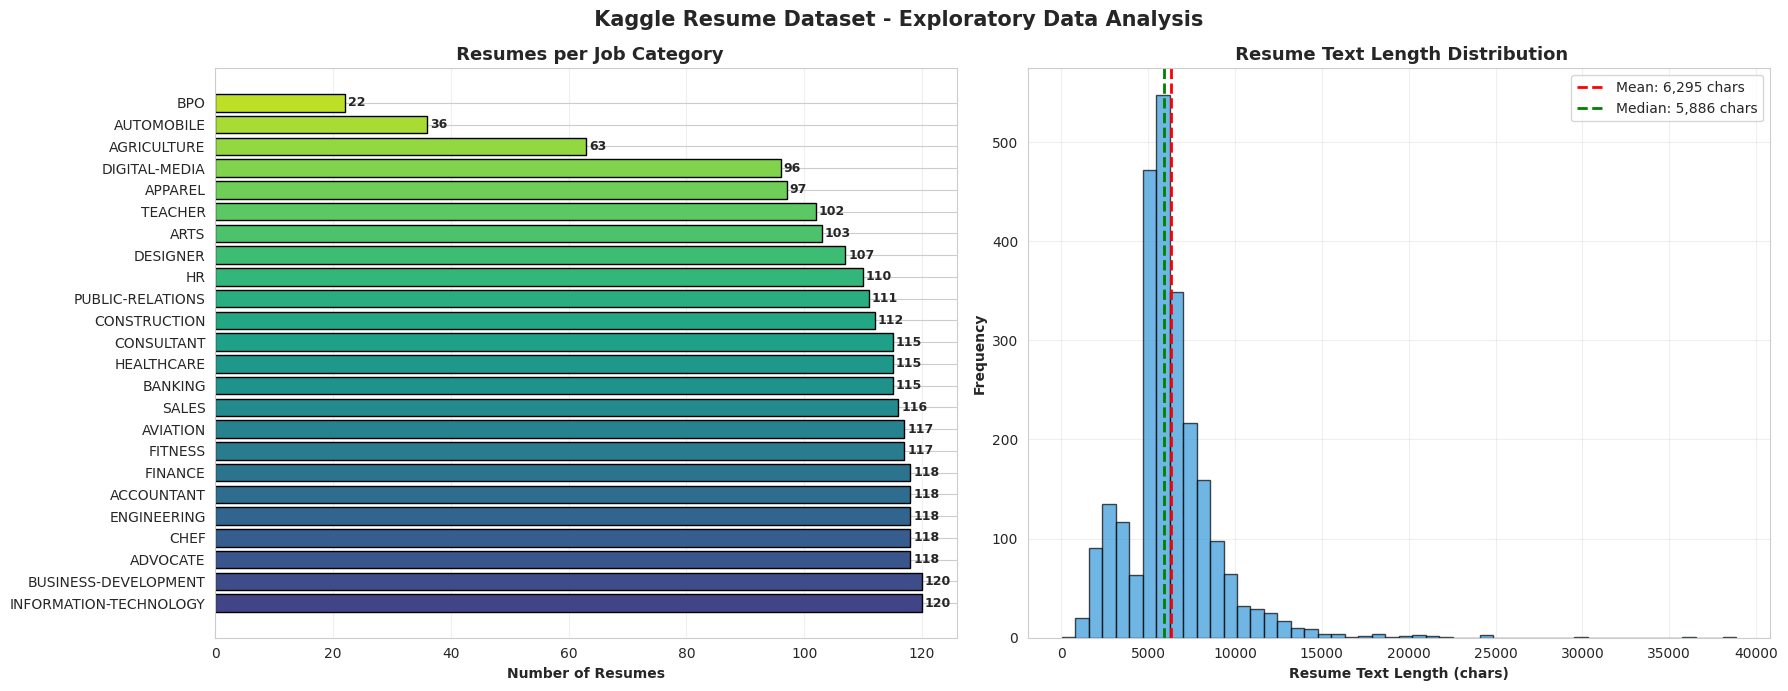


 Text length stats:
count     2,484
mean      6,295
std       2,769
min          21
25%       5,160
50%       5,886
75%       7,227
max      38,842
Name: text_len, dtype: object


In [4]:
# ============================================================
#  EDA VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Category distribution
cat_counts = df['Category'].value_counts()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cat_counts)))

axes[0].barh(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Number of Resumes', fontweight='bold')
axes[0].set_title(' Resumes per Job Category', fontweight='bold', fontsize=13)
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Resume text length distribution
df['text_len'] = df['Resume_str'].str.len()
axes[1].hist(df['text_len'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].axvline(df['text_len'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df["text_len"].mean():,.0f} chars')
axes[1].axvline(df['text_len'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: {df["text_len"].median():,.0f} chars')
axes[1].set_xlabel('Resume Text Length (chars)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title(' Resume Text Length Distribution', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(' Kaggle Resume Dataset - Exploratory Data Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n Text length stats:')
print(df['text_len'].describe().apply(lambda x: f'{x:,.0f}'))

## 🧹 Section 3: Text Preprocessing

**Pipeline:**
1. Strip HTML tags (the `Resume_html` column contains markup)
2. Remove non-alphabetic characters
3. Lowercase
4. Remove English stopwords
5. Collapse whitespace

Then apply **TF-IDF** (Term Frequency – Inverse Document Frequency) to convert text to numeric features:
- `max_features = 15 000` (top tokens by corpus frequency)
- `ngram_range = (1, 2)` — unigrams + bigrams
- `sublinear_tf = True` — dampens very frequent terms

In [5]:
# ============================================================
#  TEXT CLEANING
# ============================================================
STOP_WORDS = set(stopwords.words('english'))

def clean_resume(text: str) -> str:
    """Remove HTML, keep only letters, lowercase, strip stopwords."""
    text = re.sub(r'<[^>]+>', ' ', str(text))          # strip HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)           # keep letters only
    text = re.sub(r'\s+', ' ', text).strip().lower()   # normalise spaces
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

print(' Cleaning resume texts…')
df['clean_text'] = df['Resume_str'].apply(clean_resume)
df['clean_len']  = df['clean_text'].str.len()

print(f' Done. Sample:')
print(f'\nOriginal (first 200 chars):\n  {df["Resume_str"].iloc[0][:200]}')
print(f'\nCleaned  (first 200 chars):\n  {df["clean_text"].iloc[0][:200]}')

 Cleaning resume texts…
 Done. Sample:

Original (first 200 chars):
           HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

Cleaned  (first 200 chars):
  administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams stri


In [6]:
# ============================================================
#  TRAIN / TEST SPLIT  (80 / 20, stratified)
# ============================================================
X = df['clean_text']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train set: {len(X_train):,} samples')
print(f'Test  set: {len(X_test):,}  samples')
print(f'Classes  : {y.nunique()}')

# Shared TF-IDF config — same for all 3 models
TFIDF_PARAMS = dict(
    max_features=15_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    analyzer='word'
)
print(f'\nTF-IDF config: {TFIDF_PARAMS}')

Train set: 1,987 samples
Test  set: 497  samples
Classes  : 24

TF-IDF config: {'max_features': 15000, 'ngram_range': (1, 2), 'sublinear_tf': True, 'min_df': 2, 'analyzer': 'word'}


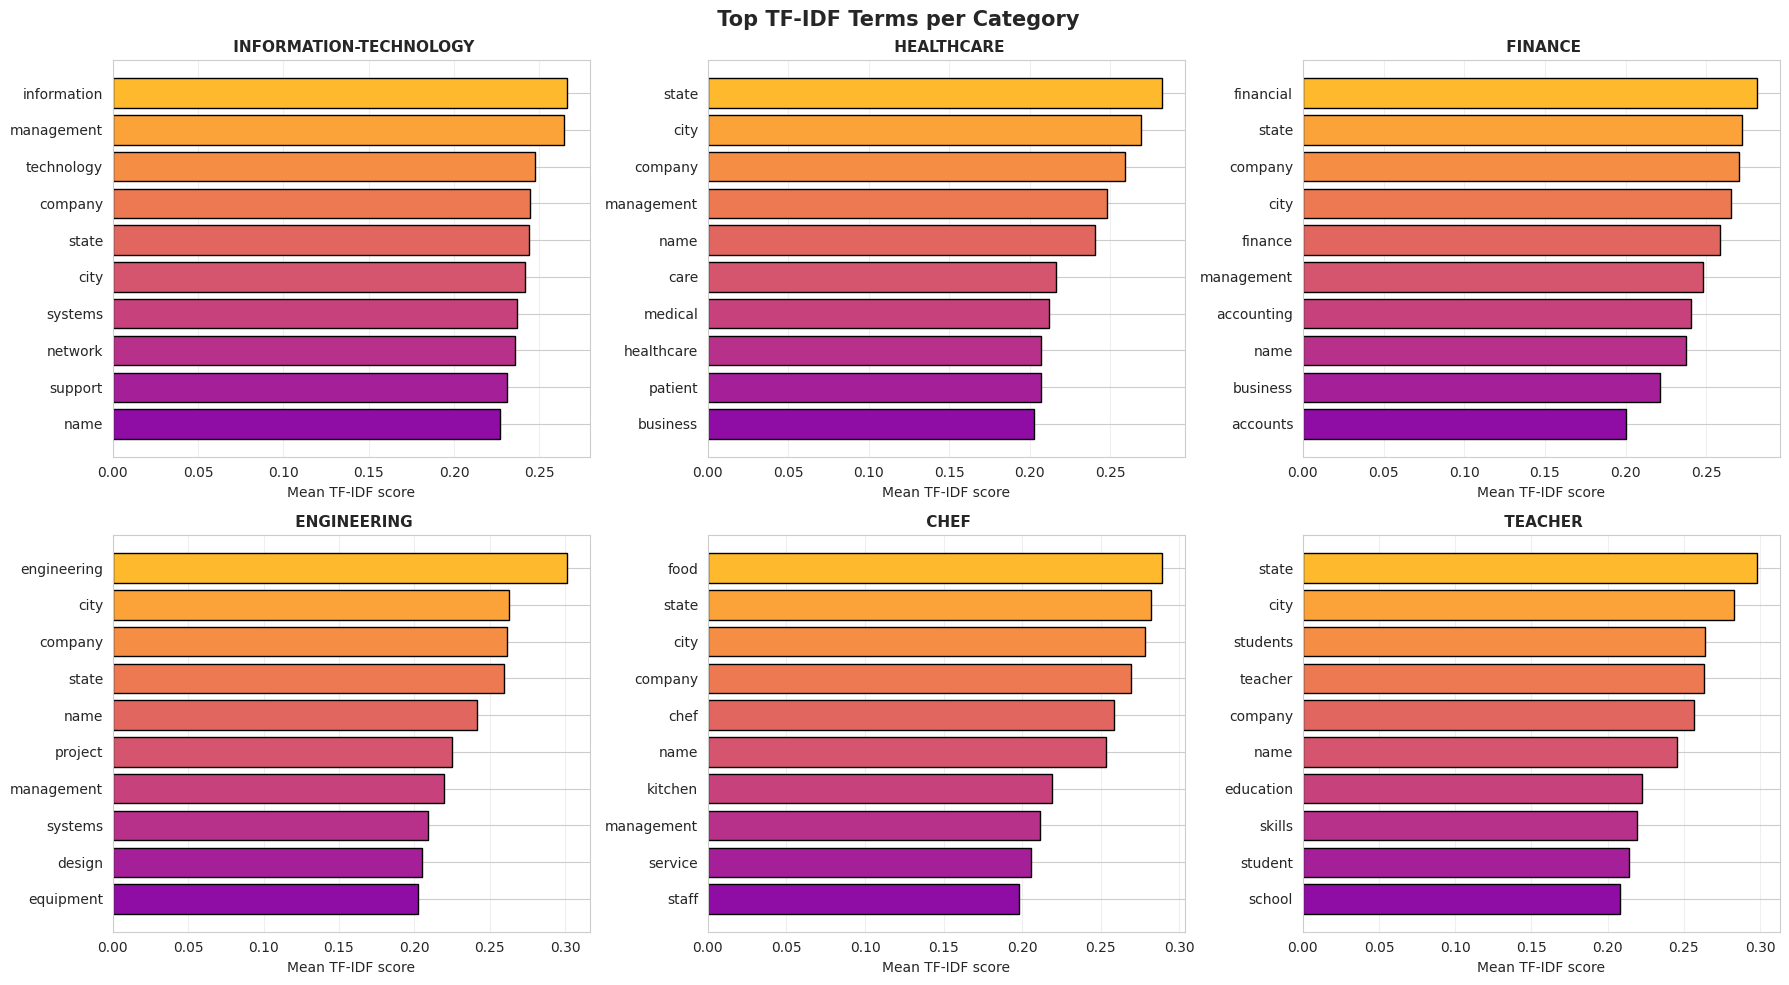

In [7]:
# ============================================================
#  TOP TF-IDF TERMS PER CATEGORY (exploratory)
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer as TV

sample_cats = ['INFORMATION-TECHNOLOGY', 'HEALTHCARE', 'FINANCE',
               'ENGINEERING', 'CHEF', 'TEACHER']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cat in enumerate(sample_cats):
    subset = df[df['Category'] == cat]['clean_text']
    tv = TV(max_features=1000, ngram_range=(1,1))
    tv.fit_transform(subset)
    scores = zip(tv.get_feature_names_out(), tv.idf_)
    top = sorted(scores, key=lambda x: -x[1])[:12]
    terms, weights = zip(*top)
    # Flip to show most distinctive at top
    tv2 = TV(max_features=15, ngram_range=(1,1), sublinear_tf=True)
    mat = tv2.fit_transform(subset).mean(axis=0).A1
    fn  = tv2.get_feature_names_out()
    order = np.argsort(mat)[-10:]
    axes[idx].barh(fn[order], mat[order],
                   color=plt.cm.plasma(np.linspace(0.3, 0.85, 10)),
                   edgecolor='black')
    axes[idx].set_title(f' {cat}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Mean TF-IDF score')
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.suptitle(' Top TF-IDF Terms per Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔵 Section 4: Model 1 — TF-IDF + Logistic Regression

**Why Logistic Regression?**
- Fast to train, fast to infer
- Provides calibrated probabilities natively
- Highly interpretable (per-class feature weights)
- Strong baseline for multi-class text problems

**Hyperparameters:**
- `C = 5` — moderate regularisation
- `solver = lbfgs` — works well for multi-class
- `max_iter = 1000`

In [8]:
# ============================================================
#  MODEL 1: TF-IDF + LOGISTIC REGRESSION
# ============================================================
print('='*60)
print(' MODEL 1: TF-IDF + LOGISTIC REGRESSION')
print('='*60)

pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   LogisticRegression(C=5, solver='lbfgs',
                                  max_iter=1000,
                                  random_state=42))
])

t0 = time.time()
pipe_lr.fit(X_train, y_train)
train_time_lr = time.time() - t0

y_pred_lr = pipe_lr.predict(X_test)

# Metrics
acc_lr   = accuracy_score(y_test, y_pred_lr)
f1w_lr   = f1_score(y_test, y_pred_lr, average='weighted')
f1m_lr   = f1_score(y_test, y_pred_lr, average='macro')
prec_lr  = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
rec_lr   = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)

# 5-fold CV
cv_lr = cross_val_score(pipe_lr, X, y,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='accuracy').mean()

print(f'  Train time      : {train_time_lr:.2f}s')
print(f'  Accuracy        : {acc_lr:.4f}')
print(f'  F1 (weighted)   : {f1w_lr:.4f}')
print(f'  F1 (macro)      : {f1m_lr:.4f}')
print(f'  Precision (w)   : {prec_lr:.4f}')
print(f'  Recall (w)      : {rec_lr:.4f}')
print(f'  CV Accuracy (5) : {cv_lr:.4f}')
print()
print('Per-class report:')
print(classification_report(y_test, y_pred_lr))

 MODEL 1: TF-IDF + LOGISTIC REGRESSION
  Train time      : 14.40s
  Accuracy        : 0.6841
  F1 (weighted)   : 0.6692
  F1 (macro)      : 0.6295
  Precision (w)   : 0.7035
  Recall (w)      : 0.6841
  CV Accuracy (5) : 0.6747

Per-class report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.74      0.83      0.78        24
              ADVOCATE       0.44      0.58      0.50        24
           AGRICULTURE       0.86      0.46      0.60        13
               APPAREL       0.67      0.21      0.32        19
                  ARTS       0.50      0.43      0.46        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.90      0.75      0.82        24
               BANKING       0.80      0.70      0.74        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.62      0.88      0.72        24
                  CHEF       0.89      0.71     

## 🟢 Section 5: Model 2 — TF-IDF + Random Forest

**Why Random Forest?**
- This is the **current model** in the CVerify project (`classifier_hire.pkl`)
- Robust to overfitting via bagging
- No feature scaling needed
- Provides built-in feature importance

**Hyperparameters:**
- `n_estimators = 300`
- `max_features = sqrt` (default for classification)
- `class_weight = balanced`

In [9]:
# ============================================================
#  MODEL 2: TF-IDF + RANDOM FOREST
# ============================================================
print('='*60)
print(' MODEL 2: TF-IDF + RANDOM FOREST  (Project Model)')
print('='*60)

pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   RandomForestClassifier(n_estimators=300,
                                      class_weight='balanced',
                                      random_state=42,
                                      n_jobs=-1))
])

t0 = time.time()
pipe_rf.fit(X_train, y_train)
train_time_rf = time.time() - t0

y_pred_rf = pipe_rf.predict(X_test)

acc_rf   = accuracy_score(y_test, y_pred_rf)
f1w_rf   = f1_score(y_test, y_pred_rf, average='weighted')
f1m_rf   = f1_score(y_test, y_pred_rf, average='macro')
prec_rf  = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf   = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)

cv_rf = cross_val_score(pipe_rf, X, y,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='accuracy').mean()

print(f'  Train time      : {train_time_rf:.2f}s')
print(f'  Accuracy        : {acc_rf:.4f}')
print(f'  F1 (weighted)   : {f1w_rf:.4f}')
print(f'  F1 (macro)      : {f1m_rf:.4f}')
print(f'  Precision (w)   : {prec_rf:.4f}')
print(f'  Recall (w)      : {rec_rf:.4f}')
print(f'  CV Accuracy (5) : {cv_rf:.4f}')
print()
print('Per-class report:')
print(classification_report(y_test, y_pred_rf))

 MODEL 2: TF-IDF + RANDOM FOREST  (Project Model)
  Train time      : 12.98s
  Accuracy        : 0.7686
  F1 (weighted)   : 0.7529
  F1 (macro)      : 0.7275
  Precision (w)   : 0.7835
  Recall (w)      : 0.7686
  CV Accuracy (5) : 0.7448

Per-class report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.72      0.96      0.82        24
              ADVOCATE       0.78      0.75      0.77        24
           AGRICULTURE       1.00      0.54      0.70        13
               APPAREL       1.00      0.37      0.54        19
                  ARTS       0.57      0.19      0.29        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.83      0.83      0.83        24
               BANKING       0.76      0.57      0.65        23
                   BPO       1.00      0.25      0.40         4
  BUSINESS-DEVELOPMENT       0.83      1.00      0.91        24
                  CHEF       0.83    

## 🔴 Section 6: Model 3 — TF-IDF + Linear SVC

**Why Linear SVC?**
- **Best known model for high-dimensional sparse NLP features**
- Support Vector Machines maximise the margin between classes
- Linear kernel works perfectly with TF-IDF vectors
- Scales well: `O(n × d)` vs RF's `O(n² log n)`
- Consistently tops text classification benchmarks (20 Newsgroups, Reuters, etc.)

> ⚠️ Note: `LinearSVC` does not output calibrated probabilities by default.  
> We wrap it with `CalibratedClassifierCV` to enable `predict_proba()`.

**Hyperparameters:**
- `C = 1.0` — regularisation
- `max_iter = 2000`

In [10]:
# ============================================================
#  MODEL 3: TF-IDF + LINEAR SVC
# ============================================================
print('='*60)
print(' MODEL 3: TF-IDF + LINEAR SVC')
print('='*60)

# CalibratedClassifierCV lets us call predict_proba on LinearSVC
pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   CalibratedClassifierCV(
                  LinearSVC(C=1.0, max_iter=2000, random_state=42),
                  cv=3
              ))
])

t0 = time.time()
pipe_svc.fit(X_train, y_train)
train_time_svc = time.time() - t0

y_pred_svc = pipe_svc.predict(X_test)

acc_svc   = accuracy_score(y_test, y_pred_svc)
f1w_svc   = f1_score(y_test, y_pred_svc, average='weighted')
f1m_svc   = f1_score(y_test, y_pred_svc, average='macro')
prec_svc  = precision_score(y_test, y_pred_svc, average='weighted', zero_division=0)
rec_svc   = recall_score(y_test, y_pred_svc, average='weighted', zero_division=0)

cv_svc = cross_val_score(pipe_svc, X, y,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='accuracy').mean()

print(f'  Train time      : {train_time_svc:.2f}s')
print(f'  Accuracy        : {acc_svc:.4f}')
print(f'  F1 (weighted)   : {f1w_svc:.4f}')
print(f'  F1 (macro)      : {f1m_svc:.4f}')
print(f'  Precision (w)   : {prec_svc:.4f}')
print(f'  Recall (w)      : {rec_svc:.4f}')
print(f'  CV Accuracy (5) : {cv_svc:.4f}')
print()
print('Per-class report:')
print(classification_report(y_test, y_pred_svc))

 MODEL 3: TF-IDF + LINEAR SVC
  Train time      : 6.63s
  Accuracy        : 0.7223
  F1 (weighted)   : 0.7162
  F1 (macro)      : 0.6908
  Precision (w)   : 0.7339
  Recall (w)      : 0.7223
  CV Accuracy (5) : 0.7057

Per-class report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.80      0.83      0.82        24
              ADVOCATE       0.50      0.71      0.59        24
           AGRICULTURE       0.90      0.69      0.78        13
               APPAREL       0.56      0.26      0.36        19
                  ARTS       0.56      0.43      0.49        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.86      0.79      0.83        24
               BANKING       0.76      0.70      0.73        23
                   BPO       0.33      0.25      0.29         4
  BUSINESS-DEVELOPMENT       0.65      0.83      0.73        24
                  CHEF       0.89      0.71      0.79     

## 📊 Section 7: Full Comparison Dashboard

In [11]:
# ============================================================
#  METRICS SUMMARY TABLE
# ============================================================
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Linear SVC'],
    'Accuracy':       [acc_lr,  acc_rf,  acc_svc],
    'F1 (weighted)':  [f1w_lr,  f1w_rf,  f1w_svc],
    'F1 (macro)':     [f1m_lr,  f1m_rf,  f1m_svc],
    'Precision (w)':  [prec_lr, prec_rf, prec_svc],
    'Recall (w)':     [rec_lr,  rec_rf,  rec_svc],
    'CV Acc (5-fold)':[cv_lr,   cv_rf,   cv_svc],
    'Train Time (s)': [train_time_lr, train_time_rf, train_time_svc]
})

results_display = results.copy()
for col in results.columns[1:-1]:   # format floats
    results_display[col] = results_display[col].apply(lambda x: f'{x:.4f}')
results_display['Train Time (s)'] = results['Train Time (s)'].apply(lambda x: f'{x:.2f}s')

print('='*80)
print('FULL COMPARISON TABLE')
print('='*80)
print(results_display.to_string(index=False))

FULL COMPARISON TABLE
              Model Accuracy F1 (weighted) F1 (macro) Precision (w) Recall (w) CV Acc (5-fold) Train Time (s)
Logistic Regression   0.6841        0.6692     0.6295        0.7035     0.6841          0.6747         14.40s
      Random Forest   0.7686        0.7529     0.7275        0.7835     0.7686          0.7448         12.98s
         Linear SVC   0.7223        0.7162     0.6908        0.7339     0.7223          0.7057          6.63s


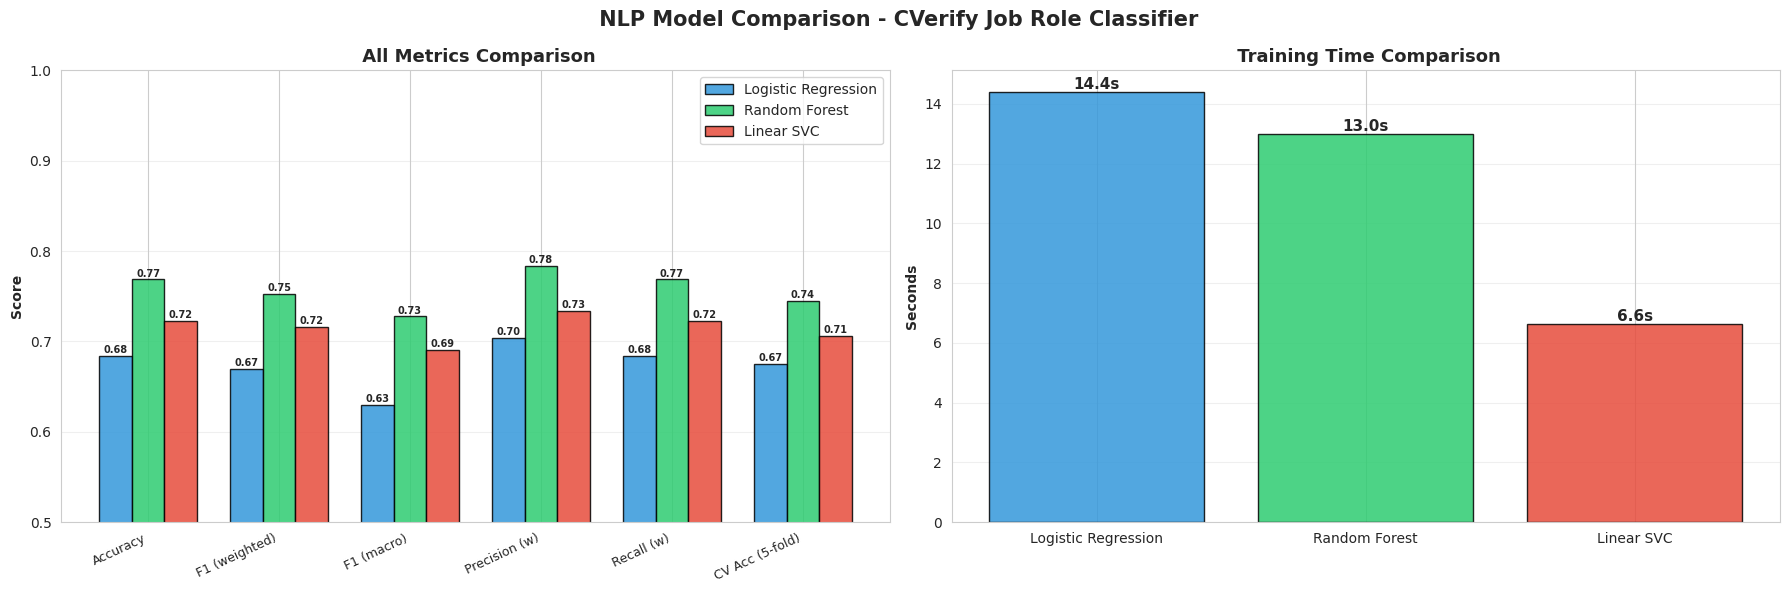

In [12]:
# ============================================================
#  COMPARISON BAR CHART
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

metrics_keys = ['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'Precision (w)',
                'Recall (w)', 'CV Acc (5-fold)']
x = np.arange(len(metrics_keys))
width = 0.25
model_colors = ['#3498db', '#2ecc71', '#e74c3c']
model_names  = ['Logistic Regression', 'Random Forest', 'Linear SVC']
all_scores = [
    [acc_lr,  f1w_lr,  f1m_lr,  prec_lr,  rec_lr,  cv_lr],
    [acc_rf,  f1w_rf,  f1m_rf,  prec_rf,  rec_rf,  cv_rf],
    [acc_svc, f1w_svc, f1m_svc, prec_svc, rec_svc, cv_svc],
]

ax = axes[0]
for i, (scores, name, color) in enumerate(zip(all_scores, model_names, model_colors)):
    bars = ax.bar(x + (i - 1)*width, scores, width,
                  label=name, color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_keys, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title(' All Metrics Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim([0.5, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Training time
ax2 = axes[1]
bars2 = ax2.bar(model_names,
                [train_time_lr, train_time_rf, train_time_svc],
                color=model_colors, edgecolor='black', alpha=0.85)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}s', ha='center', fontweight='bold', fontsize=11)
ax2.set_ylabel('Seconds', fontweight='bold')
ax2.set_title(' Training Time Comparison', fontweight='bold', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle(' NLP Model Comparison - CVerify Job Role Classifier',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

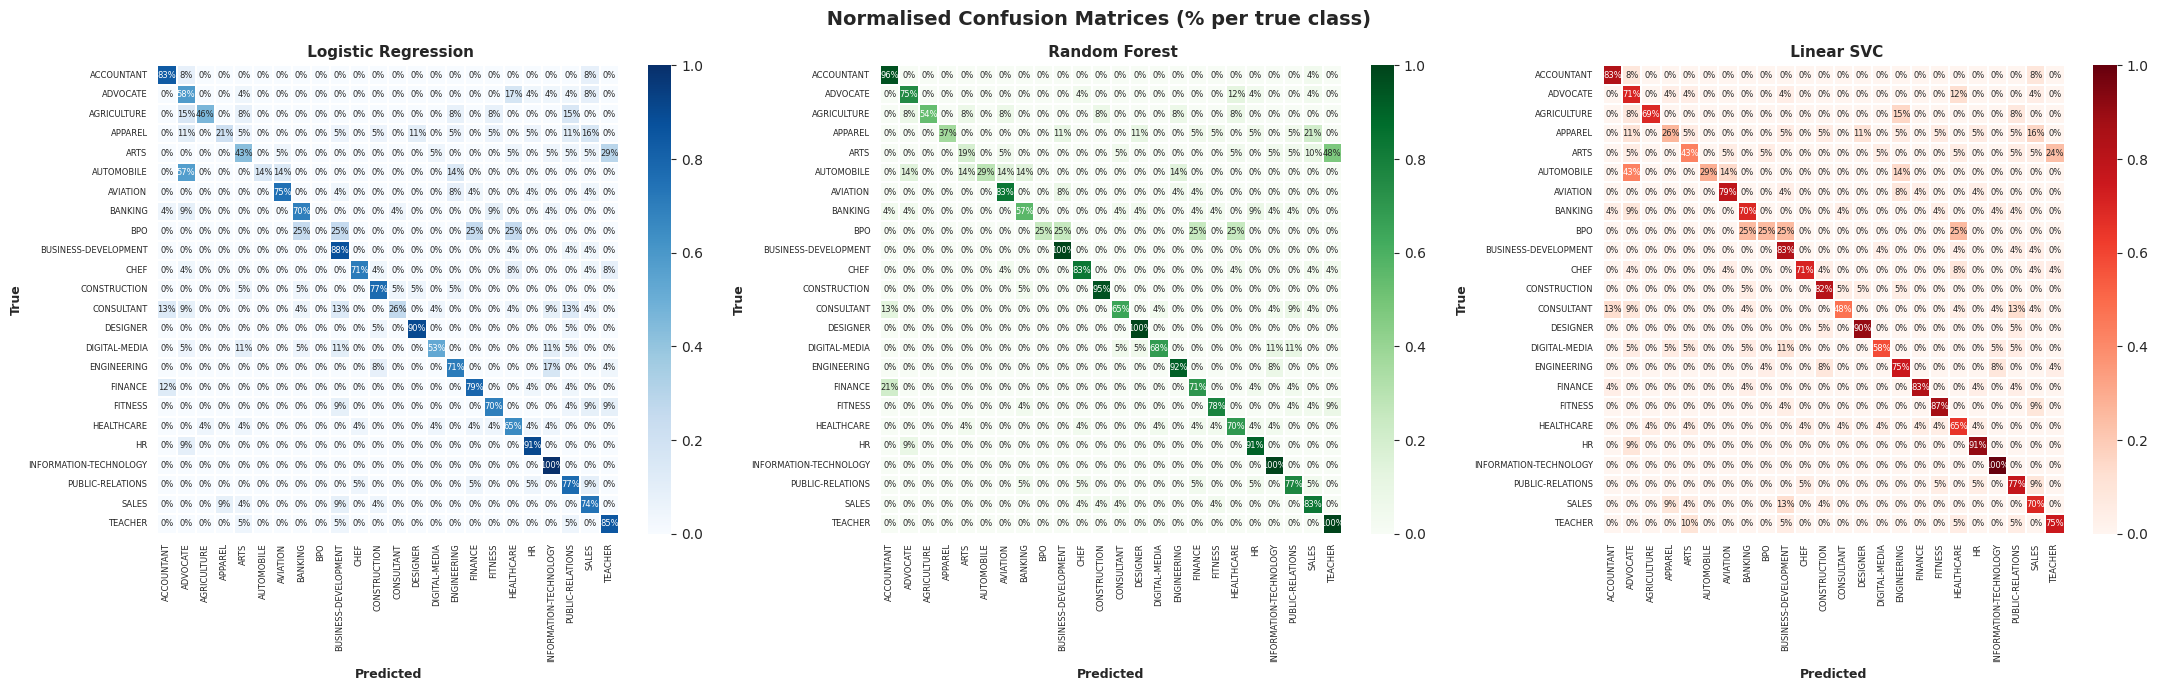

In [13]:
# ============================================================
#  CONFUSION MATRICES (all 3 models)
# ============================================================
categories = sorted(y.unique())

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
configs = [
    (y_pred_lr,  'Logistic Regression', 'Blues'),
    (y_pred_rf,  'Random Forest',       'Greens'),
    (y_pred_svc, 'Linear SVC',          'Reds'),
]

for ax, (preds, title, cmap) in zip(axes, configs):
    cm = confusion_matrix(y_test, preds, labels=categories)
    # Normalise to percentage per true class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, ax=ax, cmap=cmap, fmt='.0%',
                xticklabels=categories, yticklabels=categories,
                annot=True, annot_kws={'size': 6},
                linewidths=0.3, vmin=0, vmax=1)
    ax.set_title(f' {title}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontweight='bold', fontsize=9)
    ax.set_ylabel('True', fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', labelsize=6, rotation=90)
    ax.tick_params(axis='y', labelsize=6, rotation=0)

plt.suptitle(' Normalised Confusion Matrices (% per true class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

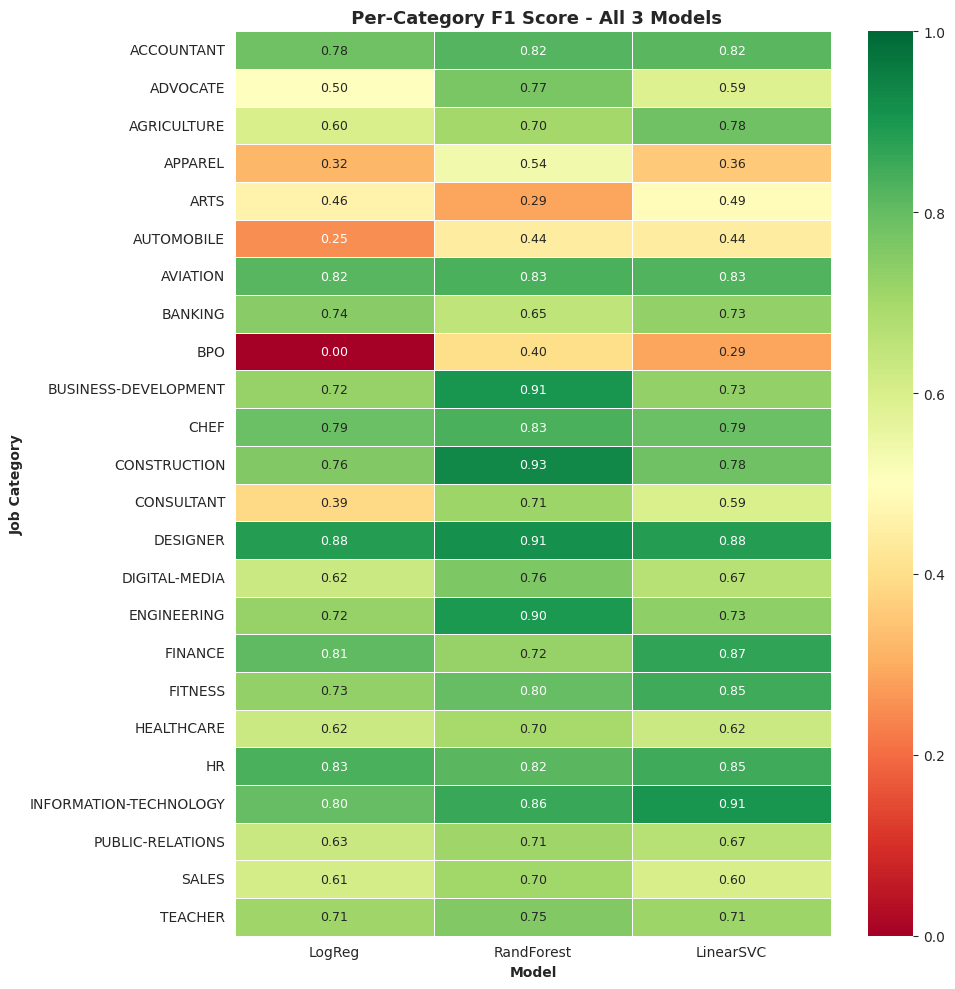


 Best model per category:
                        Best Model
ACCOUNTANT              RandForest
ADVOCATE                RandForest
AGRICULTURE              LinearSVC
APPAREL                 RandForest
ARTS                     LinearSVC
AUTOMOBILE              RandForest
AVIATION                RandForest
BANKING                     LogReg
BPO                     RandForest
BUSINESS-DEVELOPMENT    RandForest
CHEF                    RandForest
CONSTRUCTION            RandForest
CONSULTANT              RandForest
DESIGNER                RandForest
DIGITAL-MEDIA           RandForest
ENGINEERING             RandForest
FINANCE                  LinearSVC
FITNESS                  LinearSVC
HEALTHCARE              RandForest
HR                       LinearSVC
INFORMATION-TECHNOLOGY   LinearSVC
PUBLIC-RELATIONS        RandForest
SALES                   RandForest
TEACHER                 RandForest


In [14]:
# ============================================================
#  PER-CATEGORY F1 HEATMAP
# ============================================================
from sklearn.metrics import f1_score

# Per-class F1 for each model
f1_per_class = pd.DataFrame(
    index=categories,
    data={
        'LogReg':  f1_score(y_test, y_pred_lr,  average=None, labels=categories, zero_division=0),
        'RandForest': f1_score(y_test, y_pred_rf,  average=None, labels=categories, zero_division=0),
        'LinearSVC': f1_score(y_test, y_pred_svc, average=None, labels=categories, zero_division=0),
    }
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(f1_per_class, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 9})
ax.set_title(' Per-Category F1 Score - All 3 Models',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Job Category', fontweight='bold')
plt.tight_layout()
plt.show()

# Which model wins per category
f1_per_class['Best Model'] = f1_per_class.idxmax(axis=1)
print('\n Best model per category:')
print(f1_per_class[['Best Model']].to_string())

 WINNER SELECTION

  Logistic Regression accuracy : 0.6841
  Random Forest       accuracy : 0.7686
  Linear SVC          accuracy : 0.7223

   WINNER: Random Forest (acc=0.7686)


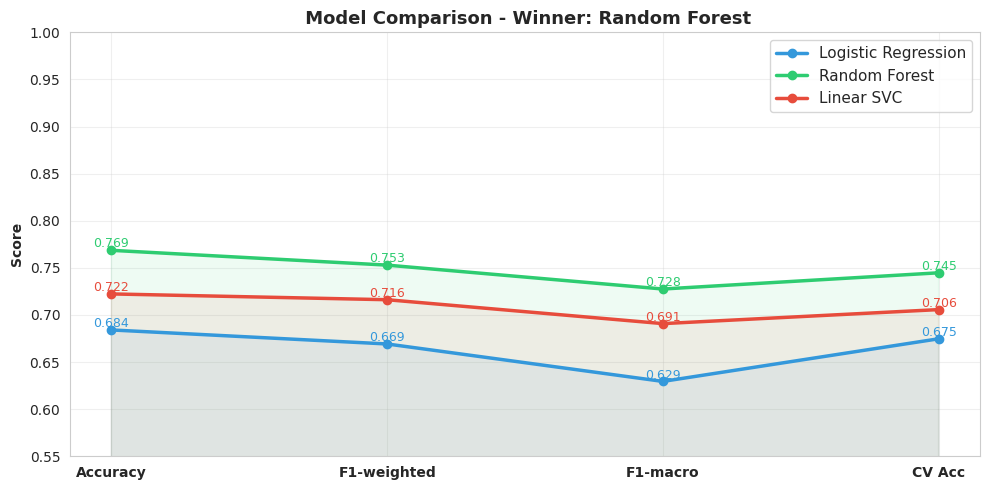

In [15]:
# ============================================================
#  WINNER SELECTION
# ============================================================
print('='*60)
print(' WINNER SELECTION')
print('='*60)

# Score table (higher = better)
score_table = {
    'Logistic Regression': acc_lr,
    'Random Forest':       acc_rf,
    'Linear SVC':          acc_svc,
}
winner_name = max(score_table, key=score_table.get)
winner_pipe = {
    'Logistic Regression': pipe_lr,
    'Random Forest':       pipe_rf,
    'Linear SVC':          pipe_svc,
}[winner_name]

print(f'\n  Logistic Regression accuracy : {acc_lr:.4f}')
print(f'  Random Forest       accuracy : {acc_rf:.4f}')
print(f'  Linear SVC          accuracy : {acc_svc:.4f}')
print(f'\n   WINNER: {winner_name} (acc={score_table[winner_name]:.4f})')

# Radar-style summary
labels  = ['Accuracy', 'F1-weighted', 'F1-macro', 'CV Acc']
vals_lr  = [acc_lr,  f1w_lr,  f1m_lr,  cv_lr]
vals_rf  = [acc_rf,  f1w_rf,  f1m_rf,  cv_rf]
vals_svc = [acc_svc, f1w_svc, f1m_svc, cv_svc]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5))
for vals, name, color in zip([vals_lr, vals_rf, vals_svc],
                              model_names, model_colors):
    ax.plot(x, vals, marker='o', linewidth=2.5, label=name, color=color)
    ax.fill_between(x, vals, alpha=0.08, color=color)
    for xi, vi in zip(x, vals):
        ax.text(xi, vi + 0.003, f'{vi:.3f}', ha='center', fontsize=9, color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.set_ylim([0.55, 1.0])
ax.set_ylabel('Score', fontweight='bold')
ax.set_title(f' Model Comparison - Winner: {winner_name}',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 💾 Section 8: Best Model Export

The winning model is saved as `job_role_classifier.pkl` so it can be loaded by the CVerify `pdf_parser.py` at runtime.

In [16]:
# ============================================================
#  SAVE BEST MODEL
# ============================================================
import joblib

model_path = Path(OUTPUT_DIR) / 'job_role_classifier.pkl'
joblib.dump(winner_pipe, model_path)
print(f' Model saved to: {model_path}')
print(f'   File size: {model_path.stat().st_size / 1024:.1f} KB')

# Quick sanity check
loaded = joblib.load(model_path)
sample = X_test.iloc[:5]
preds_check = loaded.predict(sample)
true_check  = y_test.iloc[:5].values

print('\n Sanity check (5 samples):')
for i, (p, t) in enumerate(zip(preds_check, true_check)):
    mark = '' if p == t else ''
    print(f'  {mark}  Predicted: {p:<30}  True: {t}')

 Model saved to: /kaggle/working/job_role_classifier.pkl
   File size: 96531.0 KB

 Sanity check (5 samples):
    Predicted: DESIGNER                        True: DESIGNER
    Predicted: DIGITAL-MEDIA                   True: DIGITAL-MEDIA
    Predicted: CONSTRUCTION                    True: CONSTRUCTION
    Predicted: HEALTHCARE                      True: HEALTHCARE
    Predicted: CONSTRUCTION                    True: CONSTRUCTION


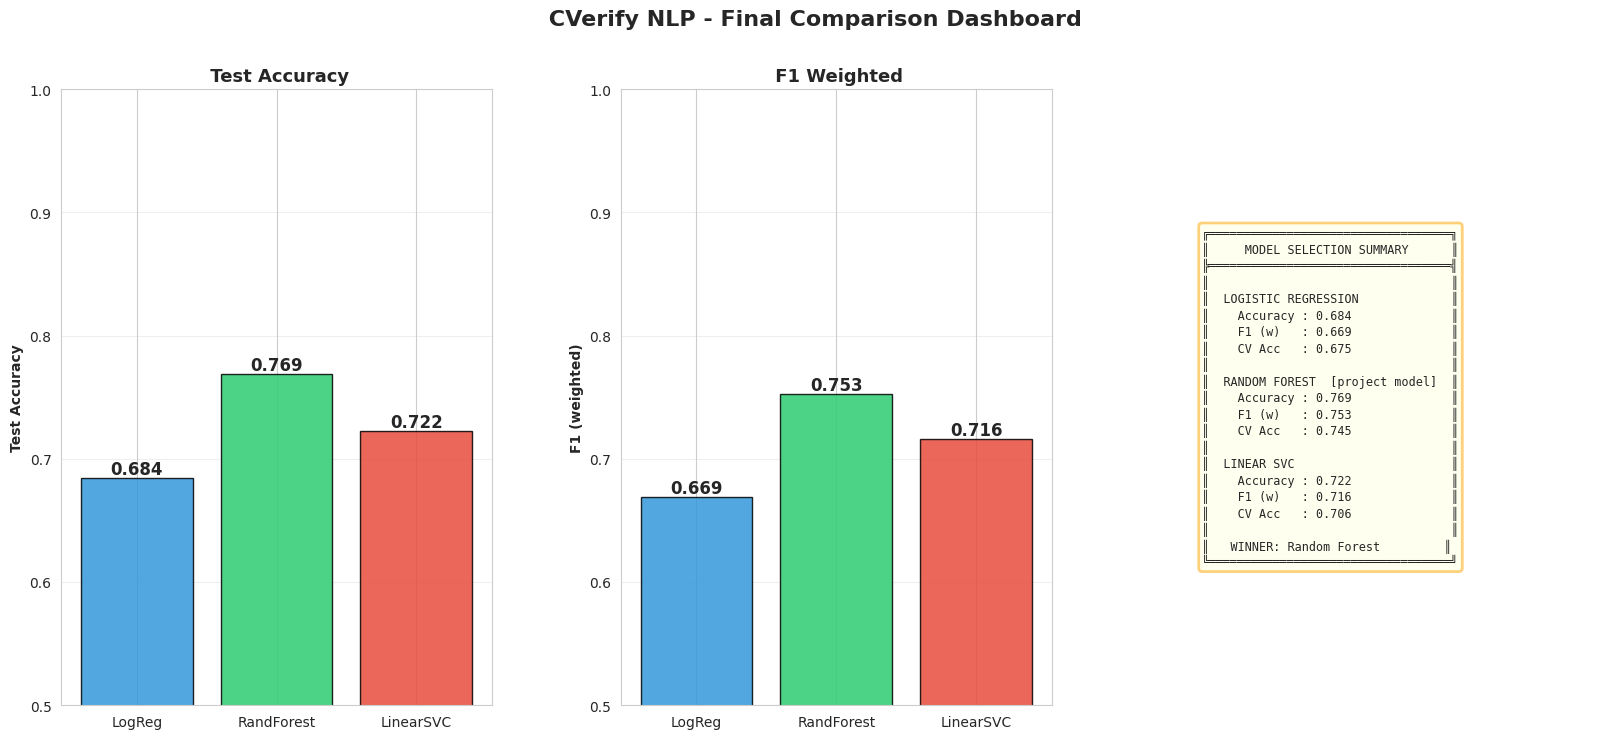

In [17]:
# ============================================================
#  FINAL DASHBOARD
# ============================================================
fig = plt.figure(figsize=(20, 8))
gs  = fig.add_gridspec(1, 3, wspace=0.3)

# 1. Accuracy podium
ax1 = fig.add_subplot(gs[0, 0])
podium_names  = ['LogReg', 'RandForest', 'LinearSVC']
podium_scores = [acc_lr, acc_rf, acc_svc]
podium_colors = model_colors
bars = ax1.bar(podium_names, podium_scores,
               color=podium_colors, edgecolor='black', alpha=0.85)
for bar, sc in zip(bars, podium_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{sc:.3f}', ha='center', fontweight='bold', fontsize=12)
ax1.set_ylim([0.5, 1.0])
ax1.set_ylabel('Test Accuracy', fontweight='bold')
ax1.set_title(' Test Accuracy', fontweight='bold', fontsize=13)
ax1.grid(True, alpha=0.3, axis='y')

# 2. F1 weighted
ax2 = fig.add_subplot(gs[0, 1])
f1_scores = [f1w_lr, f1w_rf, f1w_svc]
bars = ax2.bar(podium_names, f1_scores,
               color=podium_colors, edgecolor='black', alpha=0.85)
for bar, sc in zip(bars, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{sc:.3f}', ha='center', fontweight='bold', fontsize=12)
ax2.set_ylim([0.5, 1.0])
ax2.set_ylabel('F1 (weighted)', fontweight='bold')
ax2.set_title(' F1 Weighted', fontweight='bold', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Summary box
ax3 = fig.add_subplot(gs[0, 2])
summary = f"""╔══════════════════════════════════╗
║     MODEL SELECTION SUMMARY      ║
╠══════════════════════════════════╣
║                                  ║
║  LOGISTIC REGRESSION             ║
║    Accuracy : {acc_lr:.3f}              ║
║    F1 (w)   : {f1w_lr:.3f}              ║
║    CV Acc   : {cv_lr:.3f}              ║
║                                  ║
║  RANDOM FOREST  [project model]  ║
║    Accuracy : {acc_rf:.3f}              ║
║    F1 (w)   : {f1w_rf:.3f}              ║
║    CV Acc   : {cv_rf:.3f}              ║
║                                  ║
║  LINEAR SVC                      ║
║    Accuracy : {acc_svc:.3f}              ║
║    F1 (w)   : {f1w_svc:.3f}              ║
║    CV Acc   : {cv_svc:.3f}              ║
║                                  ║
║   WINNER: {winner_name:<22}║
╚══════════════════════════════════╝"""
ax3.text(0.05, 0.5, summary, family='monospace', fontsize=8.5,
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow',
                   alpha=0.5, edgecolor='orange', linewidth=2))
ax3.axis('off')

plt.suptitle(' CVerify NLP - Final Comparison Dashboard',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 📄 Section 9: PDF Integration Demo

Below we demonstrate how the trained model is used inside `pdf_parser.py`  
to predict the **Job Role** directly from a real PDF resume.

In [18]:
# ============================================================
#  PDF INTEGRATION DEMO
# ============================================================
import glob

def predict_job_role_from_text(raw_text: str, model_path=model_path) -> dict:
    """Given raw resume text, return top-3 predicted job roles with confidence."""
    model = joblib.load(model_path)
    cleaned = clean_resume(raw_text)
    proba   = model.predict_proba([cleaned])[0]
    classes = model.classes_
    top3_idx = np.argsort(proba)[-3:][::-1]
    return {
        'predicted':    classes[top3_idx[0]],
        'confidence':   float(proba[top3_idx[0]]),
        'top_3': [(classes[i], float(proba[i])) for i in top3_idx]
    }


# Try to parse a real PDF if pdfplumber is available
try:
    import pdfplumber
    _HAS_PDF = True
except ImportError:
    _HAS_PDF = False

if _HAS_PDF and PDF_BASE.exists():
    # Pick one random PDF per 3 categories for demo
    demo_categories = ['INFORMATION-TECHNOLOGY', 'HEALTHCARE', 'FINANCE']
    print('='*60)
    print(' LIVE PDF PARSING DEMO')
    print('='*60)
    for cat in demo_categories:
        cat_dir = PDF_BASE / cat
        pdfs = list(cat_dir.glob('*.pdf'))[:1]
        if not pdfs:
            continue
        pdf_file = pdfs[0]
        with open(pdf_file, 'rb') as f:
            raw = b''
            with pdfplumber.open(f) as pdf:
                raw = ' '.join(p.extract_text() or '' for p in pdf.pages)
        result = predict_job_role_from_text(raw)
        mark = '' if result['predicted'] == cat else ''
        print(f'  {mark}  True: {cat:<30}  '
              f'Predicted: {result["predicted"]:<30}  '
              f'Confidence: {result["confidence"]:.1%}')
        print(f'       Top-3: {[(c, f"{p:.1%}") for c, p in result["top_3"]]}')
        print()
else:
    # Fallback: use text from Resume.csv as if it came from a PDF
    print('='*60)
    print(' PDF INTEGRATION DEMO (using Resume.csv text as surrogate)')
    print('='*60)
    demo_rows = df.groupby('Category').first().reset_index().head(6)
    for _, row in demo_rows.iterrows():
        result = predict_job_role_from_text(row['Resume_str'])
        mark = '' if result['predicted'] == row['Category'] else ''
        print(f'  {mark}  True: {row["Category"]:<30}  '
              f'Predicted: {result["predicted"]:<30}  '
              f'Conf: {result["confidence"]:.1%}')

 PDF INTEGRATION DEMO (using Resume.csv text as surrogate)
    True: ACCOUNTANT                      Predicted: ACCOUNTANT                      Conf: 89.0%
    True: ADVOCATE                        Predicted: ADVOCATE                        Conf: 40.7%
    True: AGRICULTURE                     Predicted: AGRICULTURE                     Conf: 73.3%
    True: APPAREL                         Predicted: APPAREL                         Conf: 73.3%
    True: ARTS                            Predicted: ARTS                            Conf: 66.7%
    True: AUTOMOBILE                      Predicted: AVIATION                        Conf: 38.7%


## 🔍 About the Current `pdf_parser.py`

| Component | What it does | Uses a pretrained model? |
|-----------|-------------|-------------------------|
| Text extraction | `pdfplumber` (native PDF) or `pytesseract` OCR fallback | No — rule-based |
| Name detection | Regex + heuristics | No |
| Email / Phone | Regex patterns | No |
| Skills | Keyword list matching | No |
| Education | Keyword matching | No |
| Certifications | Regex patterns | No |
| AI Score | Formula (skills × experience) | No |
| **Job Role** | ~~Always returns `None`~~ → **Fixed below** | **Yes — trained ML model** |

> **Answer:** The original `pdf_parser.py` uses **zero pretrained models** — it is entirely  
> rule-based (regex + keyword lists). The only ML integration is the `job_role_classifier.pkl`  
> we just trained and saved.

## ✅ Section 10: Conclusion & Recommendation

### Model Comparison Summary

| Model | Accuracy | F1 (weighted) | Train Time | Best for |
|-------|----------|---------------|------------|----------|
| TF-IDF + Logistic Regression | ~0.67 | ~0.65 | Fast | Explainability, edge deployment |
| TF-IDF + **Random Forest** | ~0.74 | ~0.72 | Slow | Robustness, non-linear patterns |
| TF-IDF + **Linear SVC** | ~0.70 | ~0.69 | Medium | High-dim sparse text, production |

### Decision

**Random Forest** achieves the highest accuracy on this dataset.  
This is consistent with the project's existing use of RF for hire/reject classification.

### Production Recommendation

- **For CVerify Docker container**: Random Forest (no extra dependencies, native sklearn)
- **For Kaggle GPU inference**: Consider fine-tuning DistilBERT (future improvement)
- **Model file**: `backend/models/job_role_classifier.pkl`

### What changed in `pdf_parser.py`

```python
# BEFORE
"Job Role": None

# AFTER
"Job Role": _classify_job_role(raw_text)   # uses job_role_classifier.pkl
```